In [1]:
import os
import sys
import shutil
import subprocess
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "strings").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

# Ensure TeX binaries are visible inside the notebook kernel environment.
TEX_BIN = "/Library/TeX/texbin"
if Path(TEX_BIN).exists() and TEX_BIN not in os.environ.get("PATH", "").split(":"):
    os.environ["PATH"] = f"{TEX_BIN}:{os.environ.get('PATH', '')}"

import numpy as np
import emcee
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import brentq


def has_tex_cmr10():
    if shutil.which("latex") is None or shutil.which("kpsewhich") is None:
        return False
    result = subprocess.run(
        ["kpsewhich", "cmr10.tfm"],
        capture_output=True,
        text=True,
        check=False,
    )
    return bool(result.stdout.strip())


USE_TEX = has_tex_cmr10()
mpl.rcParams["text.usetex"] = USE_TEX
mpl.rcParams["font.family"] = "serif"
if USE_TEX:
    mpl.rcParams["font.serif"] = ["Computer Modern Roman"]
else:
    mpl.rcParams["mathtext.fontset"] = "cm"
    print("TeX font cmr10.tfm not found; using Matplotlib mathtext fallback.")


In [2]:
%load_ext autoreload
%autoreload 2
import strings as cs

BACKEND = "python"  # use "python" for the original scipy backend

if BACKEND == "fortran":
    sys.path.insert(0, str(PROJECT_ROOT / "fortran_backend"))
    import cosmic_cl_backend as fcl

    compute_cl_backend = fcl.compute_cl
    theory_settings = dict(
        n_k=48,
        n_chi=1024,
        k_min=1.0e-4,
        k_max=1.0e-1,
    )
elif BACKEND == "python":
    compute_cl_backend = cs.compute_cl
    theory_settings = dict(
        N_k=30,
        max_workers=8,
        progress=True,
    )
else:
    raise ValueError("BACKEND must be 'fortran' or 'python'")

BACKEND, theory_settings


('python', {'N_k': 30, 'max_workers': 8, 'progress': True})

In [3]:
ACT = cs.ACTDR6
USE_FULL_ACT_COVARIANCE = False
PLANCK18 = cs.PLANCK18
PLANCK13 = cs.PLANCK13

def infer_contiguous_integer_bins(centers, first_lmin):
    bins = []
    lo = int(first_lmin)
    for center in centers:
        hi = int(round(2.0 * float(center) - lo))
        if hi < lo:
            raise ValueError(f"Could not infer a valid bin around L={center}")
        bins.append((lo, hi))
        lo = hi + 1
    return np.asarray(bins, dtype=int)


def planck13_bandpower_factor(ell):
    ell = np.asarray(ell, dtype=float)
    return 1.0e8 * ell**2 * (ell + 1.0)**2 / (2.0 * np.pi)


planck13_bins_all = infer_contiguous_integer_bins(PLANCK13.L, first_lmin=2)

datasets = {
    "ACT": ACT,
    "Planck18": PLANCK18,
    "Planck13": PLANCK13,
}

comparisons = {
    "ACT": ("ACT",),
    "Planck18": ("Planck18",),
    "Planck13": ("Planck13",),
    "ACT+Planck18": ("ACT", "Planck18"),
    "ACT+Planck13": ("ACT", "Planck13"),
}

colors = {
    "ACT": "tab:blue",
    "Planck18": "tab:purple",
    "Planck13": "tab:green",
    "ACT+Planck18": "tab:red",
    "ACT+Planck13": "black",
}

plot_style = {
    "ACT": dict(fmt="o", color=colors["ACT"], ms=4),
    "Planck18": dict(fmt="^", color=colors["Planck18"], ms=4),
    "Planck13": dict(fmt="s", color=colors["Planck13"], ms=4),
}

Lmin = 0
Lmax = 3000
masks = {
    name: (spec.L > Lmin) & (spec.L < Lmax)
    for name, spec in datasets.items()
}

full_cov_inv = {}
if USE_FULL_ACT_COVARIANCE:
    act_mask = masks["ACT"]
    act_cov = cs.ACTCOV[np.ix_(act_mask, act_mask)]
    full_cov_inv["ACT"] = np.linalg.inv(act_cov)

# Center-only theory uses floor, matching the old scipy notebook convention.
# Planck13 below uses binned theory instead of this center approximation.
ell_theory = {
    name: np.floor(spec.L[masks[name]]).astype(int)
    for name, spec in datasets.items()
}

planck13_bins = planck13_bins_all[masks["Planck13"]]

for name, spec in datasets.items():
    ell = spec.L[masks[name]]
    msg = (
        f"{name}: {len(ell)} bins, "
        f"data L = {ell.min():.1f} to {ell.max():.1f}, "
        f"center theory ell = {ell_theory[name].min()} to {ell_theory[name].max()}"
    )
    if name == "Planck13":
        msg += (
            f", binned theory ell = {planck13_bins[:, 0].min()} "
            f"to {planck13_bins[:, 1].max()}"
        )
    print(msg)


ACT: 18 bins, data L = 14.5 to 1874.0, center theory ell = 14 to 1874
Planck18: 14 bins, data L = 17.5 to 1602.8, center theory ell = 17 to 1602
Planck13: 20 bins, data L = 6.0 to 1111.5, center theory ell = 6 to 1111, binned theory ell = 2 to 1147


In [4]:
Gmu_ref = 1.0e-4
P_fixed = 1.0


def bin_scaled_theory_to_center_cl(centers, bins, cl_by_ell, scale_factor):
    # Center-inferred top-hat bandpower approximation used for the 6.8-ish
    # Planck13 reproduction.
    cl_binned = []
    for center, (lo, hi) in zip(centers, bins):
        ell = np.arange(lo, hi + 1)
        weights = 2 * ell + 1
        scaled_theory = scale_factor(ell) * cl_by_ell[ell]
        scaled_bandpower = np.average(scaled_theory, weights=weights)
        cl_binned.append(scaled_bandpower / scale_factor(center))
    return np.asarray(cl_binned)


def compute_planck13_binned_reference():
    ell_full = np.arange(planck13_bins[:, 0].min(), planck13_bins[:, 1].max() + 1)
    cl_full = compute_cl_backend(
        Gmu_ref,
        P_fixed,
        ell_arr=ell_full,
        **theory_settings,
    )
    cl_by_ell = np.zeros(ell_full.max() + 1)
    cl_by_ell[ell_full] = cl_full

    return bin_scaled_theory_to_center_cl(
        PLANCK13.L[masks["Planck13"]],
        planck13_bins,
        cl_by_ell,
        planck13_bandpower_factor,
    )


def compute_center_reference(dataset_name, spec):
    return compute_cl_backend(
        Gmu_ref,
        P_fixed,
        ell_arr=ell_theory[dataset_name],
        **theory_settings,
    )


CL_ref_center = {}
CL_ref = {}
for name, spec in datasets.items():
    CL_ref_center[name] = compute_center_reference(name, spec)

    if name == "Planck13":
        CL_ref[name] = compute_planck13_binned_reference()
    else:
        CL_ref[name] = CL_ref_center[name]

ratio = CL_ref["Planck13"] / CL_ref_center["Planck13"]
print(
    "Planck13 binned/center theory ratio: "
    f"first bin = {ratio[0]:.3f}, second bin = {ratio[1]:.3f}"
)


Computing Cl:   0%|          | 0/14 [00:00<?, ?it/s]/Users/antoidicherianlonappan/Desktop/cosmic_strings/strings/cl.py:54: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  inner, _ = quad(inner_integrand, 0, chi_star, args=(k,), limit=200)
Computing Cl: 100%|██████████| 1146/1146 [02:16<00:00,  8.37it/s]

Planck13 binned/center theory ratio: first bin = 1.354, second bin = 1.088


In [5]:
def model_cl(dataset_name, Gmu):
    return CL_ref[dataset_name] * (Gmu / Gmu_ref)**2


def chi2_dataset(dataset_name, Gmu):
    spec = datasets[dataset_name]
    mask = masks[dataset_name]
    model = model_cl(dataset_name, Gmu)
    residual = spec.CL[mask] - model
    if dataset_name in full_cov_inv:
        return residual @ full_cov_inv[dataset_name] @ residual
    return np.sum((residual / spec.ER[mask])**2)


def chi2_comparison(comparison_name, Gmu):
    return sum(
        chi2_dataset(dataset_name, Gmu)
        for dataset_name in comparisons[comparison_name]
    )


def upper_limit_from_chi2(chi2_func, delta_chi2=4.0, first_upper=3.0e-4):
    chi2_zero = chi2_func(0.0)

    def objective(Gmu):
        return chi2_func(Gmu) - chi2_zero - delta_chi2

    upper = first_upper
    while objective(upper) < 0:
        upper *= 2

    return brentq(objective, 0.0, upper)


upper_2sigma = {
    name: upper_limit_from_chi2(lambda Gmu, name=name: chi2_comparison(name, Gmu))
    for name in comparisons
}
upper_2sigma


{'ACT': 5.383326282290709e-05,
 'Planck18': 0.0001545176170106438,
 'Planck13': 6.866286876763033e-05,
 'ACT+Planck18': 5.311924673516875e-05,
 'ACT+Planck13': 4.5976687897400556e-05}

In [6]:
def log_prior(theta):
    Gmu = theta[0]
    if 0.0 < Gmu < 0.1:
        return 0.0
    return -np.inf


def log_likelihood_comparison(theta, comparison_name):
    Gmu = theta[0]
    if Gmu <= 0.0:
        return -np.inf
    return -0.5 * chi2_comparison(comparison_name, Gmu)


def log_probability_comparison(theta, comparison_name):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_comparison(theta, comparison_name)

In [7]:
# Optional MCMC version of the same CL likelihoods.
# The deterministic limits above are usually enough for a 1D comparison.
nwalkers = 20
ndim = 1
nsteps = 10000
initial_scale = 0.5 * max(upper_2sigma.values())
initial = initial_scale * (1.0 + 0.1 * np.random.randn(nwalkers, ndim))

samplers = {}
for name in comparisons:
    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        lambda theta, name=name: log_probability_comparison(theta, name),
    )
    sampler.run_mcmc(initial, nsteps, progress=True)
    samplers[name] = sampler


  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:03<00:00, 3316.03it/s]


In [8]:
samples = {
    name: sampler.get_chain(discard=500, thin=10, flat=True)[:, 0]
    for name, sampler in samplers.items()
}

upper_2sigma_mcmc = {
    name: np.percentile(values, 95)
    for name, values in samples.items()
}
upper_2sigma_mcmc


{'ACT': 5.056410906441584e-05,
 'Planck18': 0.00013675616261445286,
 'Planck13': 6.142214035108324e-05,
 'ACT+Planck18': 4.939122389092257e-05,
 'ACT+Planck13': 4.390590473792536e-05}

Removed no burn in
Removed no burn in
ACT 95% upper limit: Gmu < 5.056e-05
ACT+Planck 13 95% upper limit: Gmu < 4.391e-05


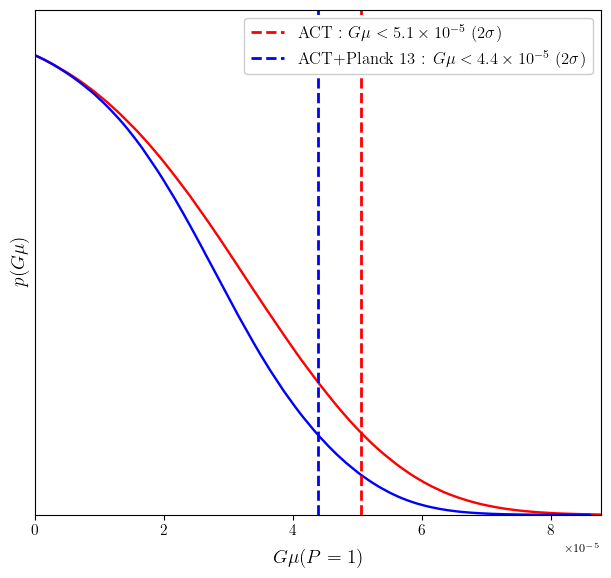

In [10]:
# ACT-only 1D posterior with getdist, following the requested plotting style
from getdist import MCSamples, plots

samples_1d_actp13 = np.asarray(samples["ACT+Planck13"])
samples_1d_act = np.asarray(samples["ACT"])
gd_samples_actp13 = MCSamples(
    samples=samples_1d_actp13.reshape(-1, 1),
    names=["gmu"],
    labels=[r"G\\mu"],
    label="ACT+Planck 13",
    settings={"mult_bias_correction_order": 1}, ranges={"gmu": [0, None]}
)
gd_samples_act = MCSamples(
    samples=samples_1d_act.reshape(-1, 1),
    names=["gmu"],
    labels=[r"G\\mu"],
    label="ACT",
    settings={"mult_bias_correction_order": 1}, ranges={"gmu": [0, None]}
)
upper_2sigma_actp13 = np.percentile(samples_1d_actp13, 95)
upper_2sigma_act = np.percentile(samples_1d_act, 95)


g = plots.get_single_plotter(width_inch=6, ratio=1)
g.plot_1d([gd_samples_act, gd_samples_actp13], "gmu",colors=["red", "blue"],)
ax = plt.gca()
mantissa_act, exp_act = f"{upper_2sigma_act:.1e}".split("e")
mantissa_actp13, exp_actp13 = f"{upper_2sigma_actp13:.1e}".split("e")
constraint_latex_act = rf"ACT : $G\mu < {mantissa_act}\times 10^{{{int(exp_act)}}}$ (2$\sigma$)"
constraint_latex_actp13 = rf"ACT+Planck 13 : $G\mu < {mantissa_actp13}\times 10^{{{int(exp_actp13)}}}$ (2$\sigma$)"
ax.axvline(
    upper_2sigma_act,
    color="red",
    linestyle="--",
    linewidth=2,
    label=constraint_latex_act,
 )
ax.axvline(
    upper_2sigma_actp13,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=constraint_latex_actp13,
 )
ax.set_xlabel(r"$G\mu (P=1)$", fontsize=14)
ax.set_ylabel(r"$p(G\mu)$", fontsize=14)
ax.legend(loc="upper right", fontsize=12,frameon=True, framealpha=1, facecolor="white")

print(f"ACT 95% upper limit: Gmu < {upper_2sigma_act:.3e}")
print(f"ACT+Planck 13 95% upper limit: Gmu < {upper_2sigma_actp13:.3e}")
plt.savefig("plots/Gmu_Constraint_Plot.pdf", dpi=300, bbox_inches='tight')